# Practical 7: heat equation

Anna Chen (yc4406)

## Abstract

Vertical heat flow across an ice sheet varies with time $t$ and the vertical position $z$. This study considers the time-dependent heat equation at an ice divide, and solves assuming that heat only flowing vertically, the vertical strain rate $w$ is constant and uniform, and the heat flux into the ice sheet equals the geothermal heat flux, $G$. The steady-state temperature profile across ice sheet height shows non-linear, roughly logarithmic decrease from the base (at around $-15.5$ ºC) to the surface (fixed at $-20$ ºC). Then, we considered two cases, one where the surface temperature is fixed at $-20$ ºC, and another where it decreases linearly with altitude (i.e., ice thickness $H$). We perturbed **ice sheet thickness** ($H \in [500, 4000]$ m) and **annual accumulation rate** ($a \in [0.2, 2.0]$ m/yr). Basal temperature increases with increasing ice thickness for both cases. When surface temperature varies with $H$, the rate of increase slows. However, basal temperature when $ H > 1000m$ is above 0ºC, which is physically unrealistic, since ice melts above 0ºC. When increasing $a$, modeled basal temperature decreased from $\approx 4$ ºC to $\approx -15$ ºC, with decreasing rate of temperature change with higher accumulation rate. Lastly, by perturbing both $H$ and $a$, we observe very different results for whether we set the surface temperature as varying with $H$ or not. If surface temperature is fixed, the highest basal temperature is reached at low $a$ and high $H$, and lowest basal temperature vice versa; basal temperature ranges $[-15, 10]$ ºC. In parallel, if the surface temperature decreases with $H$, the highest basal temperature is also at high $H$, but now at high $a$; the lowest is at high $H$ and low $a$; basal temperature ranges $[-40, 0]$ ºC. These results show that setting varying surface temperature reverses the affects of ice sheet thickness on basal temperature. Physically, the varying surface temperature results show a much more plausible basal temperature range ($\leq 0$ ºC), which matches with our intuitive expectations, since no 4000m-thick ice sheet would only be $-20$ ºC on the surface. This study exemplifies how glacial heat flow is a non-linear function of ice sheet thickness, annual accumulation rate, surface temperature, and more. Further fine-tuning of physical parameters is necessary to increase the credibility of ice temperature physics.

## Background

We will solve the time-dependent heat equation at an ice divide. We assume that heat only flows vertically, so we will use the one-dimensional version of the equation:

$$
\frac{\partial T}{\partial t} = -  w \frac{\partial T}{\partial z} +  \alpha\frac{\partial^2 T}{\partial z^2} 
$$

where $T$ is the temperature, which varies with time $t$ and vertical position $z$, $w$ is the vertical velocity, defined as positive upwards, $\alpha$ is the thermal diffusivity. 

We will impose a constant uniform vertical strain rate. 

$$
w(z) = -\frac{az}{H}, 
$$

where $H$ is the ice thickness, and $a$ is the accumulation rate. This expression can be derived from the shallow ice appproximation by differentiating the SIA expression for the horizontal flow sped $u$ with respect to the horizontal position $x$ and integrating the negative of the result with respect to $z$. 

For boundary conditions we will fix the temperature at the surface and fix the gradient of the temperature at the base of the ice sheet so that the heat flux into the ice sheet equals the geothermal heat flux, $G$: 

$$
\frac{\partial T}{\partial z} = \frac{G}{k}.
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Task 1

Solve the heat equation with basal boundary condition:
$$
\frac{\partial T}{\partial z} = - \frac{G}{k}
$$
where $G=0.060$ W/m2 is the geothermal heat flux and $k=2.3$ W/mK is the thermal conductivity in the ice.


In [2]:
# time domain
dt_years = 1;                       # time step in years
seconds_per_year = 365*24*60*60     # approximate number of seconds in year
dt = dt_years*seconds_per_year;     # time step in seconds
t_total_years = 10000;                # total length of the simulation in years
Time = t_total_years*seconds_per_year; # total length of the simulation in seconds # Not T to avoid naming confusion

t = np.linspace(0,Time,round(Time/dt))  # the time grid, units [years]
Lt = t.size 

# space domain
dz = 10                           # grid spacing, units [m]
H = 500                          # ice thickness, units [m]
z = np.linspace(0,H,round(H/dz))  # spatial grid, units [m]
Lz = z.size  


alpha = 1.25e-6; #k/rho_i/c;      # thermal diffusivity
G = 60e-3;                        # geothermal heat flux 60 mW/m^2                 http://en.wikipedia.org/wiki/Geothermal_gradient
k = 2.3;                          # Thermal conductivity of ice at -10 in W/mK     http://www.engineeringtoolbox.com/ice-thermal-properties-d_576.html

## vertical ice velocity
a_yr = 1
a = a_yr/seconds_per_year    # accumulation in meters/second
w = -np.linspace(0,a,Lz)     # vertical velocity, sign convention is that up is positive, and we are assuming it varies from zero at the bed to a at the surface

T = np.zeros((Lt,Lz))

## initial conditions
T_surf = -20                 # surface temperature in ºC
T[0,:]  = np.linspace(0,T_surf,Lz)
T[:,-1] = T_surf             # Last depth layer is surface

### Main Loop ###
for timestep in np.arange(1,Lt):
    # step the temperature forward in time

    # save the old temperature vector
    T_old = T[timestep - 1, :]

    # Finite difference: dT/dz = (T[j+1] - T[j-1] ) / 2*dz
    dTdz = (T_old[2:] - T_old[:-2]) / (2*dz)

    # Finite difference: d2T/dz2 = (T[j+1] + T[j-1] - 2*T[j]) / dz**2
    d2Tdz2 = (T_old[2:] + T_old[:-2] - 2 * T_old[1:-1]) / dz**2

    # compute temperature at the current time step
    T[timestep, 1:-1] = T_old[1:-1] + dt * (-w[1:-1] * dTdz + alpha * d2Tdz2)

    # Apply BCs
    T[timestep,-1] = T_surf
    T[timestep,0] = T[timestep,1] + G/k*dz

print(T)


[[  0.          -0.40816327  -0.81632653 ... -19.18367347 -19.59183673
  -20.        ]
 [ -0.14812669  -0.40899625  -0.8179925  ... -19.22282382 -19.63182007
  -20.        ]
 [ -0.20720176  -0.46807133  -0.81966188 ... -19.26205408 -19.65379605
  -20.        ]
 ...
 [-15.45638739 -15.71725696 -15.97677946 ... -19.99866961 -19.99941746
  -20.        ]
 [-15.45638739 -15.71725696 -15.97677946 ... -19.99866961 -19.99941746
  -20.        ]
 [-15.45638739 -15.71725696 -15.97677946 ... -19.99866961 -19.99941746
  -20.        ]]


To plot a profile use the following. 

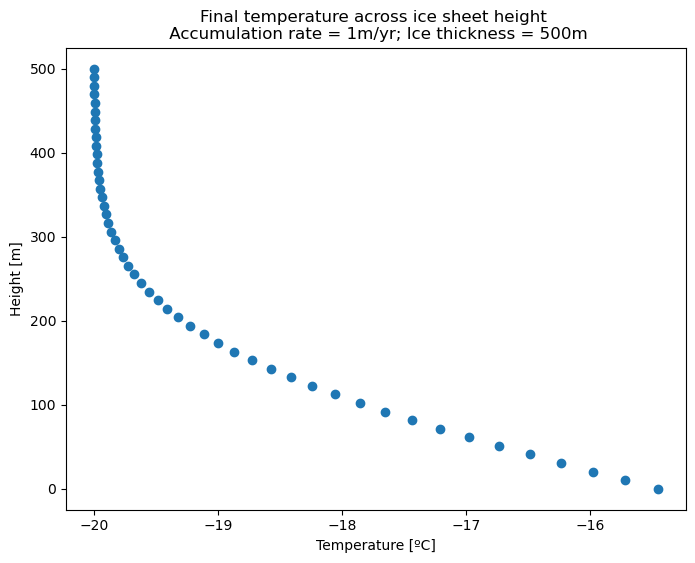

In [3]:
fig = plt.figure(figsize=(8,6))
axes = fig.add_subplot(1,1,1)
axes.plot(np.transpose(T[-1,:]),z, 'o')
axes.set_xlabel('Temperature [ºC]')
axes.set_ylabel('Height [m]')
axes.set_title(f'Final temperature across ice sheet height \n Accumulation rate = {a_yr}m/yr; Ice thickness = {H}m')

plt.show()

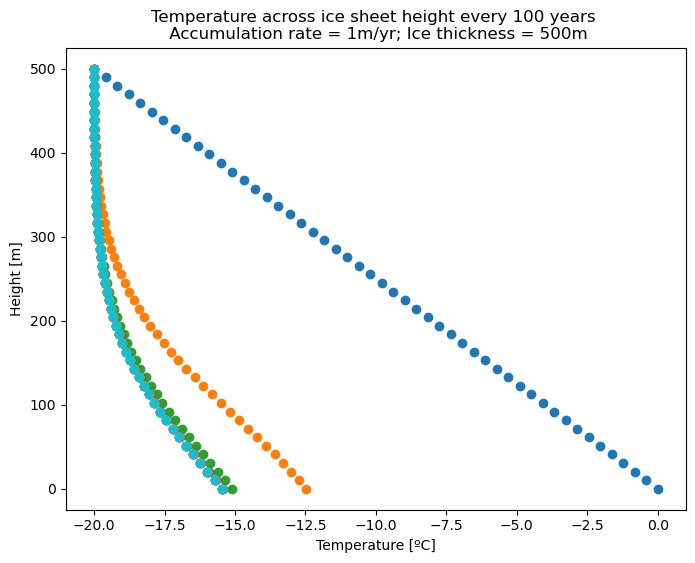

In [4]:
fig = plt.figure(figsize=(8,6))
axes = fig.add_subplot(1,1,1)

axes.plot(np.transpose(T[0:-1:1000,:]), z, 'o')
axes.set_xlabel('Temperature [ºC]')
axes.set_ylabel('Height [m]')
axes.set_title(f'Temperature across ice sheet height every 100 years \n Accumulation rate = {a_yr}m/yr; Ice thickness = {H}m')
plt.show()

In [5]:
## Use this code to plot an animation of your model results. 

# imports: you may need to import `conda install ipympl`
%matplotlib widget
import ipympl
from matplotlib import animation, rc
from IPython.display import HTML
rc('animation', html='jshtml')

def animate_ice_model_results(z, t, f, interval_between_timesteps = 1000, time_delay_between_frames = 100):
    # run this function by, e.g., `animate_ice_model_results(x, t, H)`

    # open a figure and an axes inside the figure
    fig, ax = plt.subplots()

    # set the limits of the axes
    ax.set_ylim(( z[0], z[-1]))    # the vertical axis will go from 0 to H
    ax.set_xlim((np.min(f), np.max(f)))   # the horizontal axis will got from lowest T to the highest T

    # create an line object with no data, and suppress the plot 
    line, = ax.plot([], [], lw=2);
    plt.close()

    # define a function which updates the figure, given a timestep number. This function plots the line and updates the axis labels. 
    def animate(timestep):
        line.set_data(f[timestep,:], z)                 # update the data
        ax.set_title(f"$t$ = {t[timestep]/seconds_per_year:.1f} years")  # update the title
        ax.set_ylabel("height, $z$ [m]")              # update the x label
        ax.set_xlabel("temperature $T(x,t)$ [C]")  # update the y label, change this if you want to plot something other than ice surface height
        return line

    # setup the animation 
    anim = animation.FuncAnimation(fig, animate, 
                                   frames = np.arange(0, len(t), interval_between_timesteps),
                                   interval = time_delay_between_frames, 
                                   blit=True)
    
    return anim

In [6]:
# run the function to display the animation
animate_ice_model_results(z, t, T)

## Task 2

Plot steady-state basal T against ice thickness H

In [7]:
def solve_heat_eqn(dt_years = 1,
                   t_total_years = 8e3,
                   dz = 10,
                   H = 1000,
                   alpha = 1.25e-6,
                   G = 60e-3,
                   k = 2.3,
                   a_yr = 0.1,
                   T_surf = -20,
                   surfT_varies = True):
    """
    Solves the time-dependent heat equation at the ice divide.

    Parameters:
    --------------
    dt_years: np float
        time step in years
    t_total_years: np float
        total length of the simulation in years
    dz: np float
        vertical distance step (grid spacing) in meters, from bed = 0m to surface = Hm
    H: np float
        ice thickness in meters
    alpha: np float
        thermal diffusivity in k/rho_i/c
    G: np float
        geothermal heat flux in mW/m^2                   http://en.wikipedia.org/wiki/Geothermal_gradient
    k: np float
        thermal conductivity of ice at -10ºC in W/mK       http://www.engineeringtoolbox.com/ice-thermal-properties-d_576.html
    a_yr: np float
        accumulation rate in meters/year
    T_surf: np float
        surface temperature in ºC
    surfT_varies: boolean
        if True, then surface temperature is a function of ice sheet thickness.
        else, surface temperature = -20ºC
    
    Returns:
    --------------
    T_steady: np 1D array
        steady state temperature profile from ice height 0 to H
        T_steady[-1] = -20 ºC by boundary condition definition
        T_steady[0] is the basal temperature at steady state
    """
    # Set up the time domain
    seconds_per_year = 365*24*60*60
    dt = dt_years*seconds_per_year
    T = t_total_years*seconds_per_year
    t = np.linspace(0,T,round(T/dt))    # the time grid, units [years]
    Lt = t.size 

    # Set up the space domain
    z = np.linspace(0,H,round(H/dz))    # the space grid, units [m]
    Lz = z.size
    
    # vertical ice velocity
    a = a_yr/seconds_per_year    # accumulation in meters/second
    w = -np.linspace(0,a,Lz)     # vertical velocity, sign convention is that up is positive, and we are assuming it varies from zero at the bed to a at the surface

    if surfT_varies:
        # make surface temperature a function of ice thickness
        T_surf = -10 - H*0.01     # surface temperature [ºC], at interior Antarctica, H=4000m is -50ºC

    # initial conditions
    T = np.zeros((Lt,Lz))        # T is the temperature matrix with rows = time grid, and columns = space grid
    T[0,:]  = np.linspace(0,T_surf,Lz)
    T[:,-1] = T_surf             # Last depth layer is surface

    ### Main Loop ###
    for timestep in np.arange(1,Lt):
        # step the temperature forward in time

        # save the old temperature vector
        T_old = T[timestep - 1, :]

        # Finite difference: dT/dz = (T[j+1] - T[j-1] ) / 2*dz
        dTdz = (T_old[2:] - T_old[:-2]) / (2*dz)

        # Finite difference: d2T/dz2 = (T[j+1] + T[j-1] - 2*T[j]) / dz**2
        d2Tdz2 = (T_old[2:] + T_old[:-2] - 2 * T_old[1:-1]) / dz**2

        # compute temperature at the current time step
        T[timestep, 1:-1] = T_old[1:-1] + dt * (-w[1:-1] * dTdz + alpha * d2Tdz2)

        # Apply BCs
        T[timestep,-1] = T_surf
        T[timestep,0] = T[timestep,1] + G/k*dz
    
    # Steady-state thermal profile
    T_steady = T[-1,:]

    return T_steady

In [8]:
# Set up some H that we want to try out
# H represents ice thickness
H_vectors = np.linspace(500,4000,15)
T_basal_h = []
T_basal_h_tsurf_varies = []

for H in H_vectors:
    print(f"H = {H}")
    # Surface temperature does not vary with ice sheet thickness
    T_steady = solve_heat_eqn(H = H, surfT_varies=False)
    T_basal_h.append(T_steady[0])                   # This list gathers the final basal temperature at the ice divide

    # Surface temp varies with ice sheet thickness
    T_steady = solve_heat_eqn(H = H, surfT_varies=True)
    T_basal_h_tsurf_varies.append(T_steady[0])                   # This list gathers the final basal temperature at the ice divide

H = 500.0
H = 750.0
H = 1000.0
H = 1250.0
H = 1500.0
H = 1750.0
H = 2000.0
H = 2250.0
H = 2500.0
H = 2750.0
H = 3000.0
H = 3250.0
H = 3500.0
H = 3750.0
H = 4000.0


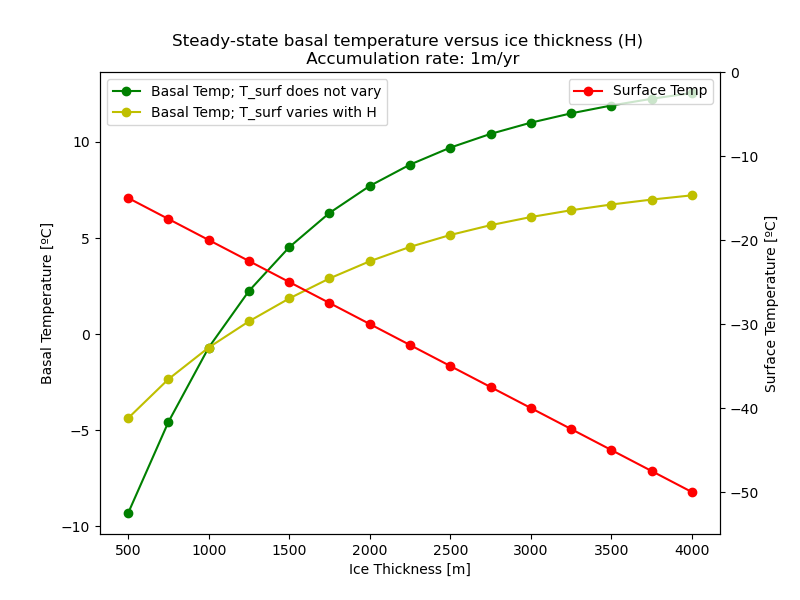

In [16]:
# Plot steady-state basal T against ice thickness H
T_surface = lambda h: -10 - h*0.01

fig = plt.figure(figsize=(8,6))
ax1 = fig.add_subplot(1,1,1)
ax1.plot(H_vectors, T_basal_h, 'go-', label='Basal Temp; T_surf does not vary')
ax1.plot(H_vectors, T_basal_h_tsurf_varies, 'yo-', label='Basal Temp; T_surf varies with H')
ax1.set_xlabel('Ice Thickness [m]')
ax1.set_ylabel('Basal Temperature [ºC]')
ax1.legend(loc = 'upper left')

ax2 = ax1.twinx()
ax2.set_ylim(-55, 0)
ax2.plot(H_vectors, T_surface(H_vectors), 'ro-', label='Surface Temp')
ax2.set_ylabel('Surface Temperature [ºC]')
ax2.legend(loc = 'upper right')
plt.title('Steady-state basal temperature versus ice thickness (H) \n Accumulation rate: 1m/yr')
plt.show()

## Task 3

Plot steady-state basal T against annual accumulation rate

In [21]:
# Set up some a that we want to try out
# a represents accumulation rate in meters per year
a_vectors = np.linspace(0.2, 2.0, 15)
T_basal_a = []

for acc_rate in a_vectors:
    print(f"a = {acc_rate}")
    T_steady = solve_heat_eqn(a_yr = acc_rate)
    T_basal_a.append(T_steady[0])                # This list gathers the final basal temperature at the ice divide

a = 0.2
a = 0.3285714285714286
a = 0.4571428571428572
a = 0.5857142857142859
a = 0.7142857142857144
a = 0.842857142857143
a = 0.9714285714285715
a = 1.1
a = 1.2285714285714286
a = 1.3571428571428572
a = 1.4857142857142858
a = 1.6142857142857143
a = 1.742857142857143
a = 1.8714285714285717
a = 2.0


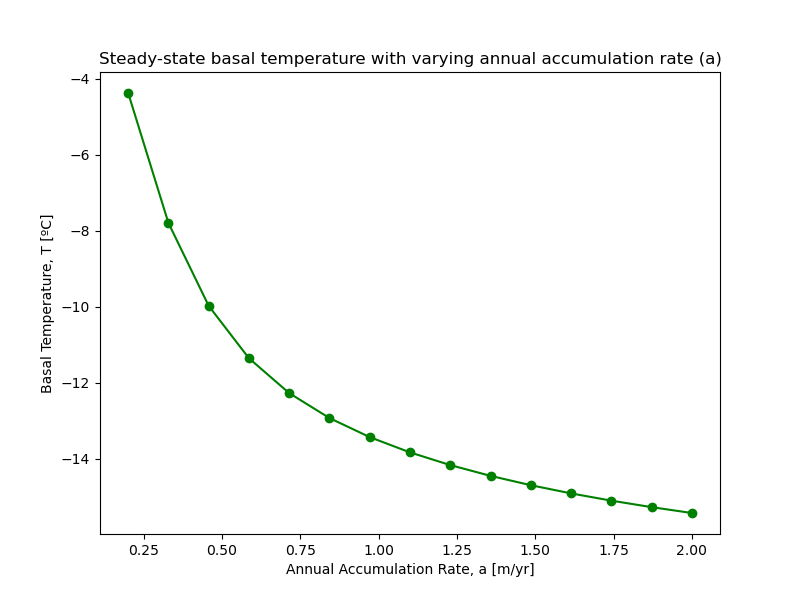

In [22]:
# Plot steady-state basal T against annual accumulation rate a
T_surface = lambda h: -10 - h*0.01

fig = plt.figure(figsize=(8,6))
ax1 = fig.add_subplot(1,1,1)
ax1.plot(a_vectors, T_basal_a, 'go-')
ax1.set_xlabel('Annual Accumulation Rate, a [m/yr]')
ax1.set_ylabel('Basal Temperature, T [ºC]')
plt.title('Steady-state basal temperature with varying annual accumulation rate (a)')
plt.show()

## Task 4

Plot steady-state basal T against ice thickness AND accumulation rate on the same plot (2-D parameter space)

In [23]:
T_basal_a_H = np.empty((10,10))
T_basal_a_H_surfT_false = np.empty((10,10))
H_array = np.linspace(500,4000, 10)
a_array = np.linspace(0.2, 2.0, 10)

# Loop over every entry in varying H and a
for i_idx, i in enumerate(H_array):
    for j_idx, j in enumerate(a_array):
        print(f'Ice thickness = {i:.3f}m;    Accumulation rate = {j:.3f}m/yr.')
        T_basal_a_H[i_idx, j_idx] = solve_heat_eqn(H = i, a_yr = j, surfT_varies=True)[0]
        T_basal_a_H_surfT_false[i_idx, j_idx] = solve_heat_eqn(H = i, a_yr = j, surfT_varies=False)[0]


Ice thickness = 500.000m;    Accumulation rate = 0.200m/yr.
Ice thickness = 500.000m;    Accumulation rate = 0.400m/yr.
Ice thickness = 500.000m;    Accumulation rate = 0.600m/yr.
Ice thickness = 500.000m;    Accumulation rate = 0.800m/yr.
Ice thickness = 500.000m;    Accumulation rate = 1.000m/yr.
Ice thickness = 500.000m;    Accumulation rate = 1.200m/yr.
Ice thickness = 500.000m;    Accumulation rate = 1.400m/yr.
Ice thickness = 500.000m;    Accumulation rate = 1.600m/yr.
Ice thickness = 500.000m;    Accumulation rate = 1.800m/yr.
Ice thickness = 500.000m;    Accumulation rate = 2.000m/yr.
Ice thickness = 888.889m;    Accumulation rate = 0.200m/yr.
Ice thickness = 888.889m;    Accumulation rate = 0.400m/yr.
Ice thickness = 888.889m;    Accumulation rate = 0.600m/yr.
Ice thickness = 888.889m;    Accumulation rate = 0.800m/yr.
Ice thickness = 888.889m;    Accumulation rate = 1.000m/yr.
Ice thickness = 888.889m;    Accumulation rate = 1.200m/yr.
Ice thickness = 888.889m;    Accumulatio

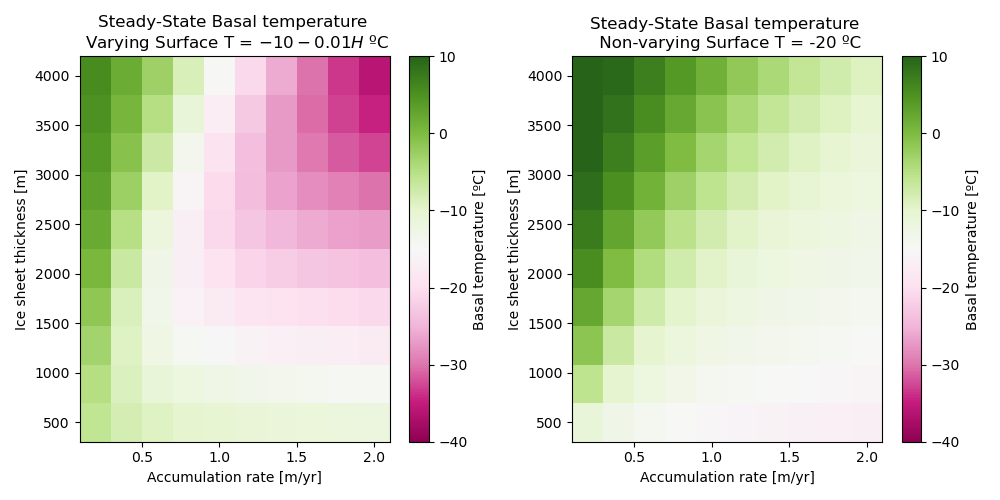

In [26]:
# Plot pcolormesh
fig = plt.figure(figsize=(10,5))

# Varying surface T with thickness
ax1 = fig.add_subplot(1,2,1)
c1 = ax1.pcolormesh(a_array, H_array, T_basal_a_H, cmap='PiYG', vmin=-40, vmax=10)
ax1.set_xlabel('Accumulation rate [m/yr]')
ax1.set_ylabel('Ice sheet thickness [m]')
ax1.set_title('Steady-State Basal temperature \n Varying Surface T = $-10 - 0.01H$ ºC')

cbar = plt.colorbar(c1, ax=ax1, label='Basal temperature [ºC]')

# Non-varying surface T
ax2 = fig.add_subplot(1,2,2)
c2 = ax2.pcolormesh(a_array, H_array, T_basal_a_H_surfT_false, cmap='PiYG', vmin=-40, vmax=10)
ax2.set_xlabel('Accumulation rate [m/yr]')
ax2.set_ylabel('Ice sheet thickness [m]')
ax2.set_title('Steady-State Basal temperature \n Non-varying Surface T = -20 ºC')

cbar = plt.colorbar(c2, ax=ax2, label='Basal temperature [ºC]')
plt.tight_layout()
plt.show()